# Portfolios {#sec-port}

Finally, we create portfolios to understand how useful the alpha signals are.

## Code setup

Loading modules:

In [ ]:
#| output: false
import os
if os.path.basename(os.getcwd()) == "src": os.chdir("..")

import numpy as np
import polars as pl
from polars import selectors as cs

In [ ]:
def count_rows(path):
    with open(path, "r", encoding = "utf-8") as file:
        row_count = sum(1 for line in file)
    return row_count

Create portfolio data:

In [ ]:
def portifolios(alpha_path: str, alpha: str, ret: str) -> pl.DataFrame:
    data = (
        pl.scan_parquet(alpha_path)
        .select(
            "permno", "ts_day_ny", "alpha_linear", "alpha_kernel", "ret_asset",
            "mcap", "numtrd", #"ret_log"
        )
        .with_columns(pl.col("alpha_linear", "alpha_kernel").shift(1).over("permno"))
        .filter(pl.col("alpha_linear").is_not_null())
        .with_columns(pl.col("*").fill_nan(None))
        .collect()
    )

    data_prepared = (
        data
        .with_columns(
            alpha_lag = pl.col(alpha).shift(1).over("permno"),
            mcap_lag = pl.col("mcap").shift(1).over("permno"),
            numtrd_lag = pl.col("numtrd").shift(1).over("permno")
        )
        .filter(pl.col("alpha_lag").is_not_null() & ~pl.col("alpha_lag").is_infinite())
        .with_columns(
            decile = pl.col("alpha_lag")
                .qcut(10, labels = [str(i) for i in range(1, 11)], allow_duplicates = True)
                .over("ts_day_ny")
                .cast(pl.String).cast(pl.Int32)
        )
    )

    daily_portfolios = (
        data_prepared
        .group_by(["ts_day_ny", "decile"])
        .agg(
            ret_ew = pl.col("ret_asset").mean(),
            ret_vw = (pl.col("ret_asset") * pl.col("mcap_lag")).sum() / pl.col("mcap_lag").sum(),
            mktcap = pl.col("mcap_lag").mean(),
            ntrades = pl.col("numtrd_lag").mean(),
            nstocks = pl.len()
        )
    )

    spread_ew = (
        daily_portfolios
        .filter(pl.col("decile") == 10)
        .select("ts_day_ny", re10 = pl.col("ret_ew"), rv10 = pl.col("ret_vw"))
        .join(
            daily_portfolios
            .filter(pl.col("decile") == 1)
            .select("ts_day_ny", re1 = pl.col("ret_ew"), rv1 = pl.col("ret_vw")),
            on = "ts_day_ny"
        )
        .select(
            "ts_day_ny",
            decile = 11,
            ret_ew = pl.col("re10") - pl.col("re1"),
            ret_vw = pl.col("rv10") - pl.col("rv1"),
            mktcap = pl.lit(None), ntrades = pl.lit(None), nstocks = pl.lit(None)
        )
    )

    return daily_portfolios.vstack(spread_ew)

In [ ]:
def table1_data(alpha_path: str, alpha: str, ret: str) -> pl.DataFrame:
    daily_portfolios = portifolios(alpha_path, alpha, ret)

    T = daily_portfolios.select("ts_day_ny").n_unique()

    table_1_stats = (
        daily_portfolios
        .group_by("decile")
        .agg(
            mret = pl.col(ret).mean() * 252 * 100,
            stddev = pl.col(ret).std() * np.sqrt(252) * 100,
            tstat = (pl.col(ret).mean() / pl.col(ret).std()) * np.sqrt(T),
            mktcap = pl.col("mktcap").mean() / 1_000_000,
            ntrades = pl.col("ntrades").mean().round(),
            nstocks = pl.col("nstocks").mean().round()
        )
        .sort("decile")
    )

    return table_1_stats

Create latex table:

In [16]:
def create_table1_latex(df_ew: pl.DataFrame, df_vw: pl.DataFrame, caption) -> str:
    def _format_row(df: pl.DataFrame, metric_col: str, fmt: str) -> str:
        vals = df.select(metric_col).to_series().to_list()
        formatted = [
            f"{v:{fmt}}" if v is not None else "" for v in vals
        ]  # handle spread mktcap/ntrades/nstocks
        return " & ".join(formatted)

    def _build_panel_body(df: pl.DataFrame, rows = "1_6") -> str:
        rows1_3 = f"""  mret & {_format_row(df, "mret", ".2f")} \\\\
  stddev & {_format_row(df, "stddev", ".2f")} \\\\
  tstat & {_format_row(df, "tstat", ".2f")} \\\\"""
        rows_4_6 = f"""
  mktcap & {_format_row(df, "mktcap", ".2f")} \\\\
  ntrades & {_format_row(df, "ntrades", ".0f")} \\\\
  nstocks & {_format_row(df, "nstocks", ".0f")} \\\\"""
        return rows1_3 + rows_4_6 if rows == "1_6" else rows1_3

    # Get ordered list of decile labels (1 to 10, plus 10-1 for spread)
    decile_ids = df_ew.select("decile").to_series().to_list()
    col_names = [
        "10-1" if d == 11 else str(d) for d in decile_ids
    ]  # decile labels
    decile_header_row = " & " + " & ".join(col_names) + " \\\\"

    # Number of decile columns + 1 rowname column = 12 total columns
    align_spec = "l" + "c" * len(col_names)

    # Construct LaTeX string
    latex_code = f"""\\begin{{table}}[H]
\\centering
\\caption{{{caption}}}
\\begin{{tabular}}{{{align_spec}}}
\\toprule
\\multicolumn{{{len(col_names) + 1}}}{{c}}{{equal-weighted decile portfolios}} \\\\
\\cmidrule(lr){{2-{len(col_names) + 1}}}
{decile_header_row}
\\cmidrule(lr){{2-{len(col_names) + 1}}}
{_build_panel_body(df_ew)}
\\vspace{{12pt}} \\\\
\\multicolumn{{{len(col_names) + 1}}}{{c}}{{value-weighted decile portfolio}} \\\\
\\cmidrule(lr){{2-{len(col_names) + 1}}}
{decile_header_row}
\\cmidrule(lr){{2-{len(col_names) + 1}}}
{_build_panel_body(df_vw, rows = "1_3")}
\\bottomrule
\\end{{tabular}}
\\end{{table}}"""

    return latex_code

## Running the portfolios and saving tables

In [ ]:
doc = """
\\documentclass[]{article}

\\usepackage[a4paper, left = 1cm, right = 1cm, top = 1cm, bottom = 1cm]{geometry}

\\usepackage{amsmath}
\\usepackage{mathtools}
\\usepackage{amssymb}

\\usepackage{multirow}
\\usepackage{multicol}
\\usepackage{booktabs}

\\usepackage{float}

\\begin{document}

"""

path = "data/portfolios/port_5min_sc1_t0.parquet"
doc += "\\section*{Linear alphas}\n\n"
df_ew = table1_data(path, alpha = "alpha_linear", ret = "ret_ew")
df_vw = table1_data(path, alpha = "alpha_linear", ret = "ret_vw")
doc += create_table1_latex(df_ew, df_vw, "Linear alphas") + "\n\n\n"
#doc += "\\newpage\n\n"

In [26]:
args = [
    {"freq": "5min", "scaler": "05", "trim_option": "ln2", "xi": "025"},
    {"freq": "5min", "scaler": 1, "trim_option": "ln2", "xi": "025"},
    {"freq": "5min", "scaler": 2, "trim_option": "ln2", "xi": "025"},
    #{"freq": "5min", "scaler": "05", "trim_option": "0"},
    #{"freq": "5min", "scaler": 1, "trim_option": "0"},
    #{"freq": "5min", "scaler": 2, "trim_option": "0"},
    #{"freq": "5min", "scaler": "05", "trim_option": "ln2"},
    #{"freq": "5min", "scaler": 1, "trim_option": "ln2"},
    #{"freq": "5min", "scaler": 2, "trim_option": "ln2"}
]

for arg in args:
    freq, scaler, trim, xi = arg["freq"], arg["scaler"], arg["trim_option"], arg.get("xi", "")
    xi_text = f"_xi{xi}" if xi else ""
    path = f"data/portfolios/port_{freq}_sc{scaler}_t{trim}{xi_text}.parquet"
    doc += f"\\section*{{Frequency: {freq}, Scaler: {scaler}, Trim: {trim}}}\n\n"

    df_ew = table1_data(path, alpha = "alpha_kernel", ret = "ret_ew")
    df_vw = table1_data(path, alpha = "alpha_kernel", ret = "ret_vw")
    doc += create_table1_latex(df_ew, df_vw, "Nonparametric alphas") + "\n\n\n"

    #doc += "\\newpage\n\n"

doc += "\\end{document}\n"

In [27]:
with open("data/portfolios/tables_v2.tex", "w") as f:
    f.write(doc)

## Long-short returns vs factors

Next, we ask whether it is possible to reproduce their performance using a combination of passive strategies.

In [83]:
args = [
    ("data/factors_raw/F-F_LT_Reversal_Factor_Daily.csv", 13, 3),
    ("data/factors_raw/F-F_Momentum_Factor_daily.csv", 13, 3),
    ("data/factors_raw/F-F_Research_Data_5_Factors_2x3_daily.csv", 4, 3),
    ("data/factors_raw/F-F_ST_Reversal_Factor_daily.csv", 13, 3)
]
dfs = []

for path, skip_init, skip_end in args:
    dfs.append(
        pl.read_csv(
            path,
            skip_rows = skip_init, n_rows = count_rows(path) - skip_init - skip_end,
            ignore_errors = True
        )
        .rename({"": "ts_day_ny"})
        .with_columns(
            pl.col("ts_day_ny").cast(pl.String)
            .str.strptime(pl.Date, format = "%Y%m%d").cast(pl.Int32),
            cs.exclude("ts_day_ny").str.strip_chars().cast(pl.Float64)
        )
    )

df = dfs[0]
for d in dfs[1:]:
    df = df.join(d, on = "ts_day_ny", how = "left")

Regress the long-short returns on the factors, in a rolling window fashion:

In [152]:
def factor_contribution(
    alpha_path: str, alpha_col: str, y_col: str, window_size: int
) -> tuple[pl.DataFrame, pl.DataFrame]:
    # 1. Define variables and regression settings
    dff = (
        portifolios(alpha_path, alpha = alpha_col, ret = "ret_ew")
        .filter(pl.col("decile") == 11)
        .select(["ts_day_ny", "ret_ew", "ret_vw"])
        .with_columns(pl.col("ts_day_ny").cast(pl.Int32))
        .join(df, on = "ts_day_ny", how = "left")
    )

    factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom", "ST_Rev", "LT_Rev"]
    coef_names = ["Intercept"] + [x.replace("_", " ") for x in factor_cols]

    # Clean dataset and extract NumPy arrays
    df_clean = dff.drop_nulls(subset=[y_col] + factor_cols).sort("ts_day_ny")

    dates = df_clean["ts_day_ny"].to_numpy()[window_size - 1 :]
    Y = df_clean[y_col].to_numpy()
    X = np.column_stack([np.ones(len(df_clean)), df_clean[factor_cols].to_numpy()])

    # 2. Iterative OLS computation using a for loop
    betas_list = []
    se_list = []
    dof = window_size - X.shape[1]  # Degrees of freedom (125 - 9)

    for i in range(window_size, len(df_clean) + 1):
        X_win = X[i - window_size : i]
        Y_win = Y[i - window_size : i]

        # OLS estimation: beta = (X'X)^(-1) X'Y
        XtX_inv = np.linalg.inv(X_win.T @ X_win)
        beta = XtX_inv @ (X_win.T @ Y_win)

        # Standard error estimation
        residuals = Y_win - (X_win @ beta)
        rss = np.sum(residuals**2)
        sigma2 = rss / dof
        se_beta = np.sqrt(np.diagonal(sigma2 * XtX_inv))

        betas_list.append(beta)
        se_list.append(se_beta)

    betas = np.array(betas_list)
    se_beta = np.array(se_list)

    # 3. Construct Polars DataFrames matching the identical output format
    df_coefs = pl.DataFrame({
        "ts_day_ny": dates,
        **{name: betas[:, i] for i, name in enumerate(coef_names)},
    })

    df_se = pl.DataFrame({
        "ts_day_ny": dates,
        **{f"se_{name}": se_beta[:, i] for i, name in enumerate(coef_names)},
    })

    return df_coefs, df_se

Plotting function:

In [198]:
import plotnine as gg
from plotnine import ggplot, aes

def factor_contribution_plot(
    df_coefs: pl.DataFrame, df_se: pl.DataFrame, window_size: int | None, ci_mult: float = 3.708,
    ncol = 2
) -> gg.ggplot:
    coef_names = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom", "ST Rev", "LT Rev"]

    # 1. Convert integer dates (YYYYMMDD) to Date type
    df_coefs_clean = df_coefs.with_columns(
        pl.from_epoch(pl.col("ts_day_ny"), "d")
    ).select(["ts_day_ny"] + coef_names if ncol == 2 else coef_names + ["ts_day_ny", "Intercept"])
    df_se_clean = df_se.with_columns(
        pl.from_epoch(pl.col("ts_day_ny"), "d")
    ).rename(
        lambda x: x.replace("se_", "")
    ).select(["ts_day_ny"] + coef_names if ncol == 2 else coef_names + ["ts_day_ny", "Intercept"])

    # 2. Unpivot (melt) DataFrames to long format
    df_coefs_long = df_coefs_clean.unpivot(
        index = "ts_day_ny", variable_name = "coef_name", value_name = "estimate"
    ).with_columns(pl.col("coef_name").cast(pl.Enum(["Intercept"] + coef_names)))

    df_se_long = df_se_clean.unpivot(
        index = "ts_day_ny", variable_name = "coef_name", value_name = "se"
    ).with_columns(pl.col("coef_name").cast(pl.Enum(["Intercept"] + coef_names)))

    # 3. Join estimates with SEs and calculate 95% confidence intervals
    df_plot = (
        df_coefs_long.join(df_se_long, on = ["ts_day_ny", "coef_name"])
        .with_columns(
            ci_lower = pl.col("estimate") - ci_mult * pl.col("se"),
            ci_upper = pl.col("estimate") + ci_mult * pl.col("se"),
        )
        .to_pandas()
    )

    # 4. Generate Plotnine faceted figure
    title = f"{window_size}-Day Rolling Factor Exposures (Estimates & 95% CI)" if window_size else "Rolling Factor Exposures (Estimates & 95% CI)"
    plot = (
        ggplot(df_plot, aes(x = "ts_day_ny")) +
        gg.geom_hline(yintercept = 0, linetype = "dashed", color = "gray", size = 0.5) +
        gg.geom_ribbon(aes(ymin = "ci_lower", ymax = "ci_upper"), alpha = 0.25) +
        gg.geom_line(aes(y = "estimate"), size = 0.5) +
        gg.facet_wrap("coef_name", ncol = ncol) +
        gg.scale_x_date(date_labels = "%Y", date_breaks = "2 year") +
        gg.theme_bw() +
        gg.theme(
            axis_text_x = gg.element_text(rotation = 45, hjust = 1)
        ) +
        gg.labs(
            x = "Date",
            y = "Estimate",
            title = title,
        )
    )

    return plot

Plotting the graphs for each option:

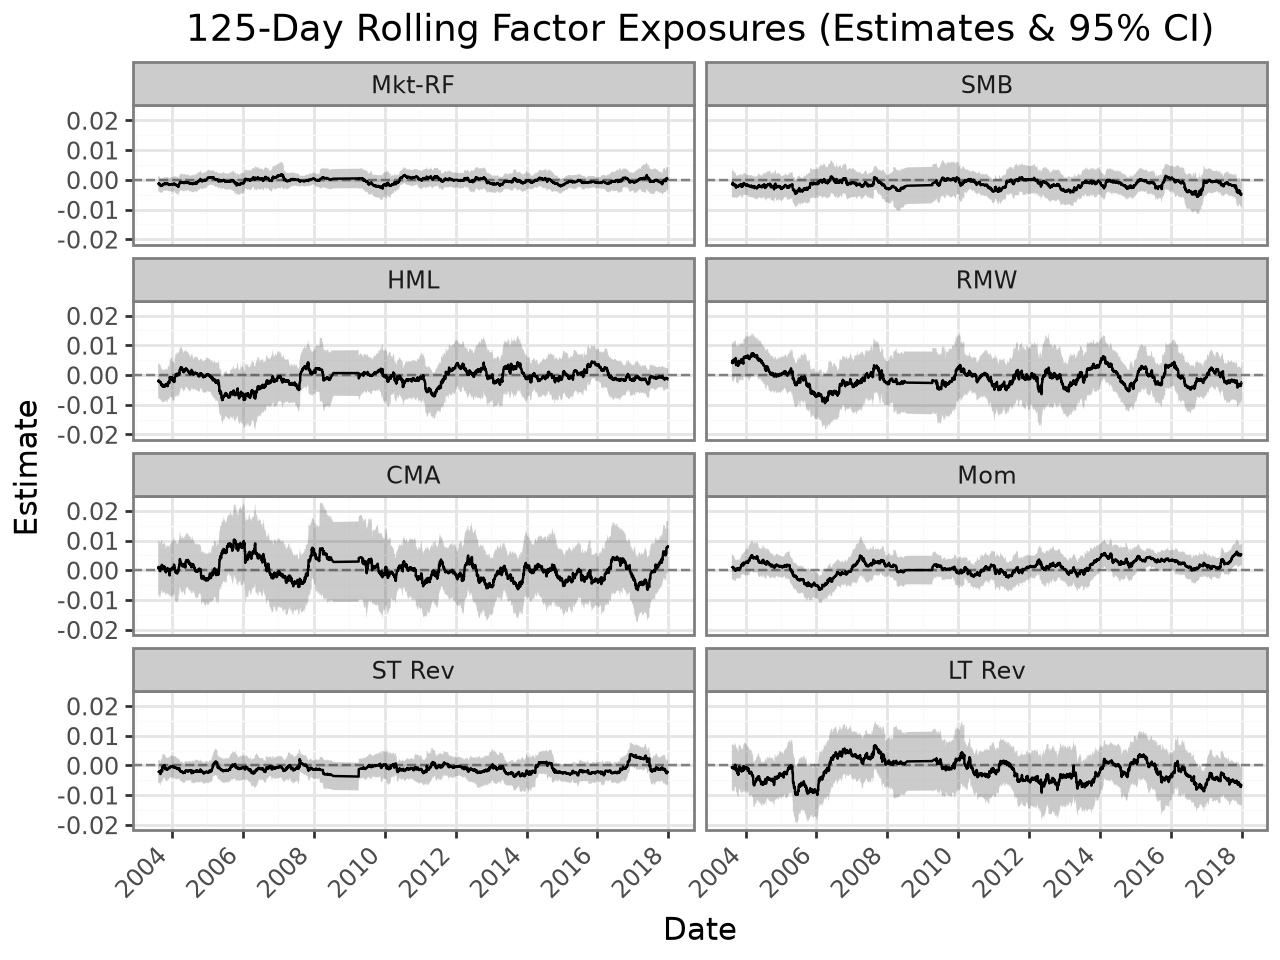

In [ ]:
df_coefs, df_se = factor_contribution(
    "data/portfolios/port_5min_sc1_tln2.parquet", "alpha_kernel", "ret_ew", 125
)
factor_contribution_plot(df_coefs, df_se, 125)

In [155]:
alpha_path = "data/portfolios/port_5min_sc1_t0.parquet"
y_col = "ret_ew"

for ws in [65, 125, 250]:
    #for ac in ["alpha_linear", "alpha_kernel"]:
    ac = "alpha_kernel"
    df_coefs, df_se = factor_contribution(alpha_path, ac, y_col, ws)
    plot = factor_contribution_plot(df_coefs, df_se, ws)
    ac = ac.replace("alpha_", "")
    plot.save(f"data/portfolios/factor_contribution_{ac}_window{ws}.png", dpi = 300)


c:\Users\ricar\OneDrive\A-Trabalho\Freelance\ra-distaso2026\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\ricar\OneDrive\A-Trabalho\Freelance\ra-distaso2026\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: data/portfolios/factor_contribution_kernel_window65.png
c:\Users\ricar\OneDrive\A-Trabalho\Freelance\ra-distaso2026\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\ricar\OneDrive\A-Trabalho\Freelance\ra-distaso2026\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: data/portfolios/factor_contribution_kernel_window125.png
c:\Users\ricar\OneDrive\A-Trabalho\Freelance\ra-distaso2026\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\ricar\OneDrive\A-Trabalho\Freelance\ra-distaso2026\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: data/portfolios/factor_con

### Old alphas

Now, we do the same but for the single-factor alphas, as in the original paper. The alphas come from the original paper's data.

In [175]:
FACTOR_COLS = ["Intercept", "Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom", "ST Rev", "LT Rev"]

def parse_old_alphas(coeff_path: str, tstats_path: str):
    # 1. Read CSVs without headers
    df_coeff = pl.read_csv(coeff_path, has_header=False)
    df_tstats = pl.read_csv(tstats_path, has_header=False)

    # 2. Convert MATLAB serial date numbers (731969 style)
    matlab_dates = df_coeff["column_1"].to_numpy()
    dates_int = (
        pl.Series(
            "ts_day_ny",
            (
                pl.Series(matlab_dates) - 719529
            ),
        )
    )

    # 3. Construct df_coefs DataFrame
    coeff_mat = df_coeff.select(df_coeff.columns[1:]).to_numpy()
    df_coefs = pl.DataFrame({
        "ts_day_ny": dates_int,
        **{col: coeff_mat[:, i] for i, col in enumerate(FACTOR_COLS)},
    })

    # 4. Invert t-stats to recover SEs: SE = |coeff / tstat|
    tstats_mat = df_tstats.select(df_tstats.columns[1:]).to_numpy()
    with np.errstate(divide="ignore", invalid="ignore"):
        se_mat = np.abs(coeff_mat / tstats_mat)
        se_mat = np.nan_to_num(se_mat, nan=0.0, posinf=0.0, neginf=0.0)

    df_se = pl.DataFrame({
        "ts_day_ny": dates_int,
        **{f"se_{col}": se_mat[:, i] for i, col in enumerate(FACTOR_COLS)},
    })

    return df_coefs, df_se

Plotting each option:

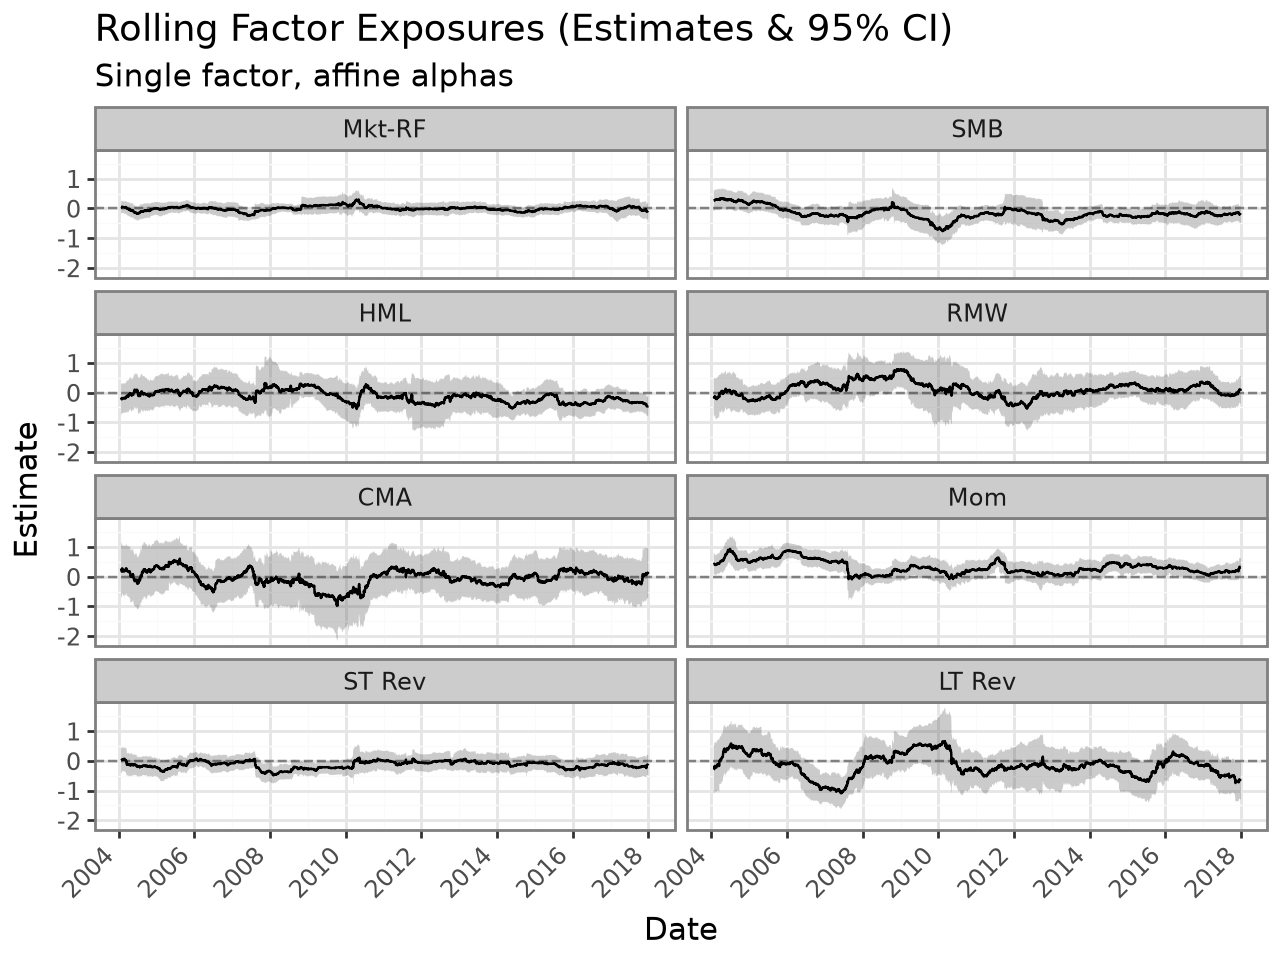

In [200]:
df_coefs_lin, df_se_lin = parse_old_alphas("data/old_alphas/lincoeff.csv", "data/old_alphas/lintstats.csv")
factor_contribution_plot(df_coefs_lin, df_se_lin, window_size = None, ncol = 2) +\
    gg.labs(subtitle = "Single factor, affine alphas")